In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, MultiHeadAttention, LayerNormalization, Dropout, GlobalAveragePooling1D
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [11]:
df = pd.read_excel('NGC-13Vs.xlsx', sheet_name='All Vs')
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

In [12]:
df.head()

,Petroleum,Bioenergy&Waste,Nuclear,Renewables (wind,GDP,Pop,Temp,Rainfall,WinsSpeed,DailySunHours,EnergyInt,RP-Gas,RP-Elec,Natural Gas
Month,,,,,,,,,,,,,,
1995-01-01,6.16,0.14,1.51,0.0,5610,57.955000,4.9,NaN,NaN,NaN,5.0,58.9,86.5,8.90
1995-02-01,6.32,0.14,1.59,0.0,5610,57.966633,6.7,NaN,NaN,NaN,5.0,59.1,86.3,7.16
1995-03-01,6.96,0.14,1.91,0.0,5610,57.978267,5.6,NaN,NaN,NaN,5.0,59.5,86.3,7.91
1995-04-01,6.08,0.14,1.78,0.0,5613,57.989900,8.9,NaN,NaN,NaN,5.0,59.2,85.6,5.75
1995-05-01,6.23,0.14,1.55,0.0,5613,58.001533,11.6,NaN,NaN,NaN,5.0,59.2,85.4,4.79


In [13]:
df['Month_Num'] = df.index.month

missing_cols = ['Rainfall', 'WinsSpeed', 'DailySunHours']
monthly_means = df.groupby('Month_Num')[missing_cols].mean()

for col in missing_cols:
    df[col] = df.apply(
        lambda row: monthly_means.loc[row['Month_Num'], col] if pd.isna(row[col]) else row[col],
        axis=1
    )

df['Month_Sin'] = np.sin(2 * np.pi * df['Month_Num'] / 12)
df['Month_Cos'] = np.cos(2 * np.pi * df['Month_Num'] / 12)
df.drop('Month_Num', axis=1, inplace=True)

target_col = 'Natural Gas'
target_idx = df.columns.get_loc(target_col)

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_data, columns=df.columns, index=df.index)

def create_sequences(data, target_col, seq_length=12):
    X, y = [], []
    target_idx = data.columns.get_loc(target_col)
    data_array = data.values
    
    for i in range(len(data_array) - seq_length):
        X.append(data_array[i:(i + seq_length)])
        y.append(data_array[i + seq_length, target_idx])
        
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_df, target_col='Natural Gas', seq_length=12)

print(f"Total NaNs after processing: {scaled_df.isna().sum().sum()}")
print(f"X shape: {X.shape} (Samples, Sequence Length, Features)")
print(f"y shape: {y.shape}")

Total NaNs after processing: 0
X shape: (343, 12, 16) (Samples, Sequence Length, Features)
y shape: (343,)


target_idx is successfully set to 13 for column 'Natural Gas'


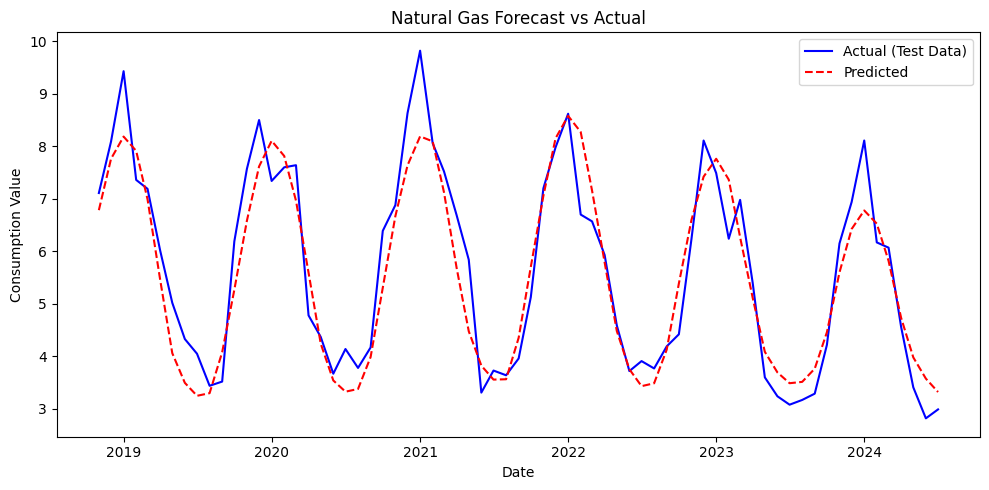

In [ ]:
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

seq_length = X.shape[1]
num_features = X.shape[2]
inputs = Input(shape=(seq_length, num_features))
lstm_out = LSTM(64, return_sequences=True)(inputs)
attention_out = MultiHeadAttention(num_heads=4, key_dim=64)(lstm_out, lstm_out)
attention_out = LayerNormalization()(lstm_out + attention_out)
attention_out = Dropout(0.2)(attention_out)
pooled = GlobalAveragePooling1D()(attention_out)
dense_out = Dense(32, activation='relu')(pooled)
outputs = Dense(1, activation='linear')(dense_out)

model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history = model.fit(X_train, y_train, epochs=20, batch_size=16, validation_data=(X_test, y_test), verbose=0)

y_pred_scaled = model.predict(X_test, verbose=0)

y_test_full = np.zeros((len(y_test), scaled_df.shape[1]))
y_pred_full = np.zeros((len(y_pred_scaled), scaled_df.shape[1]))

y_test_full[:, target_idx] = y_test.flatten()
y_pred_full[:, target_idx] = y_pred_scaled.flatten()

y_test_rescaled = scaler.inverse_transform(y_test_full)[:, target_idx]
y_pred_rescaled = scaler.inverse_transform(y_pred_full)[:, target_idx]

test_dates = scaled_df.index[split_idx + seq_length:]

plt.figure(figsize=(10, 5))
plt.plot(test_dates, y_test_rescaled, label='Actual (Test Data)', color='blue')
plt.plot(test_dates, y_pred_rescaled, label='Predicted', color='red', linestyle='--')
plt.title('Natural Gas Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Consumption Value')
plt.legend()
plt.tight_layout()

In [1]:
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
mape = np.mean(np.abs((y_test_rescaled - y_pred_rescaled) / y_test_rescaled)) * 100
r2 = r2_score(y_test_rescaled, y_pred_rescaled)


print(f"MAE : {round(mae, 3)}")
print(f"RMSE: {round(rmse, 3)}")
print(f"MAPE (%): {round(mape, 2)}")
print(f"R-squared: {round(r2, 3)}")

NameError: name 'mean_absolute_error' is not defined